In [116]:
import pandas as pd
import matplotlib.pyplot as plt

import Extrapolacio
import numpy as np
import importlib
import Prepare_data
import Predict

importlib.reload(Prepare_data)
importlib.reload(Extrapolacio)
importlib.reload(Predict)
from Prepare_data import clean_data, create_lagged_feature, rolling_mean, fill_missing_year_area_combinations
from Extrapolacio import extrapolacio, visualitzacio_extrapolacio
from Predict import train_test_split, predict, hyperparameter_tuning, visualitzacio, prediction, residual_model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from Setup import setup_environment
from sklearn.inspection import permutation_importance


In [14]:
setup_environment("Szakdolgozat")

# 1. Adatok beolvasása és előkészítése

In [2]:
df = pd.read_csv("data/crime_data.csv")
szocdem_df = pd.read_csv("data/chicago_community_areas_acs5_2013_2023_weighted_income.csv")


In [3]:
szocdem_df = szocdem_df.rename(columns={
    'acs_year': 'Year',
    'community_area': 'Community Area'
})
szocdem_df['no_hs_25plus_rate'] = szocdem_df['no_hs_25plus']/szocdem_df['pop_25plus']
szocdem_df['male_15_34_rate'] = szocdem_df['male_15_29']/szocdem_df['total_pop']

## 1.1 Crime data előkészítése - szűrés, Primary Type kiválasztása, hiányzó kombinációk kitöltése

In [4]:
col_year = 'Year'
col_area = 'Community Area'
col_features = [
    'Primary Type',
    'Longitude',
    'Latitude',
    'Arrest']
col_target = 'Primary Type'
begin_year = 2013
end_year = 2024

#if Primary Type is CRIM SEXUAL ASSAULT, then we rename it to CRIMINAL SEXUAL ASSAULT
df['Primary Type'] = df['Primary Type'].replace('CRIM SEXUAL ASSAULT', 'CRIMINAL SEXUAL ASSAULT')

data_target, data_year = clean_data(df,col_year,col_features,col_area,col_target,begin_year,end_year)
# Biztosítjuk, hogy a Primary Type string típusú legyen és eltávolítjuk a whitespace karaktereket
data_target['Primary Type'] = data_target['Primary Type'].astype(str).str.strip()
Primary_Types = data_target['Primary Type'].unique()

In [5]:
Primary_Types = data_target['Primary Type'].unique()
crime_type_df_filled = fill_missing_year_area_combinations(
    data_target,
    Primary_Types,
    all_year=data_target['Year'].unique(),
    all_area=data_target['Community Area'].unique(),
    year_col='Year',
    area_col='Community Area',
    count_col='counts'
)

## 1.2 Szociodemográfiai adatok extrapolációja 2024-re, vizualizáció, összekapcsolás a bűnözési adatokkal

In [6]:
feature = 'total_pop', 'weighted_avg_income', 'employment_rate', 'unemployment_rate', 'per_capita_income', 'poverty_rate', 'no_hs_25plus_rate', 'male_15_34_rate'
degree = 4
target_year = 2024
col = 'Year'
col_area = 'Community Area'
szocdem_2024=extrapolacio(szocdem_df, feature,col,col_area , degree, target_year)
feature_list = list(feature)
feature_list.append('Year')
feature_list.append('Community Area')
szocdem_osszes = pd.concat([szocdem_df[feature_list], szocdem_2024], ignore_index=True)

In [20]:
crime_szocdem = data_year.merge(szocdem_osszes, on=['Year', 'Community Area'], how='left')
crime_szocdem_per_type = crime_type_df_filled.merge(szocdem_osszes, on=['Year', 'Community Area'], how='left')
# Biztosítjuk, hogy a Primary Type string típusú legyen és eltávolítjuk a whitespace karaktereket
crime_szocdem_per_type['Primary Type'] = crime_szocdem_per_type['Primary Type'].astype(str).str.strip()

### 1.2.2 Extrapoláció hibája - 2023-as adatokkal összehasonlítva

In [9]:
degree = 4
szocdem_2023_extrapol = extrapolacio(szocdem_df, feature,col,col_area , degree, 2023)

In [10]:
szocdem_2023_actual = szocdem_df[szocdem_df['Year'] == 2023][feature_list].reset_index(drop=True)

In [11]:
comparison_2023 = szocdem_2023_extrapol.merge(szocdem_2023_actual, on=['Year', 'Community Area'], suffixes=('_extrapol', '_actual'))


In [12]:
id_cols = ['Year', 'Community Area']
# Kigyűjtjük a feature neveket a suffixek nélkül
features = [c.replace('_actual', '') for c in comparison_2023.columns if '_actual' in c]

new_column_order = id_cols.copy()
for f in features:
    new_column_order.append(f + '_actual')
    new_column_order.append(f + '_extrapol')
    # Akár egy hiba-oszlopot is beszúrhatsz ide azonnal:
    comparison_2023[f + '_diff'] = comparison_2023[f + '_actual'] - comparison_2023[f + '_extrapol']
    new_column_order.append(f + '_diff')

comparison_2023 = comparison_2023[new_column_order]

In [15]:
for f in features:
    error = np.abs((comparison_2023[f + '_actual'] - comparison_2023[f + '_extrapol']) / comparison_2023[f + '_actual']).mean() * 100
    Extrapol_hiba = pd.concat([Extrapol_hiba, pd.DataFrame({'Feature': [f], 'Hiba (%)': [error]})], ignore_index=True)


NameError: name 'Extrapol_hiba' is not defined

In [ ]:
col_area = [1]
visualitzacio_extrapolacio(szocdem_osszes, feature, col, col_area)

# 2. Modellépítés - szociodemográfiai adatokkal kiegészítve,rolling mean feature-ökkel, típusok szerinti bontásban is

In [21]:
Crime_szocdem_lagged= create_lagged_feature(crime_szocdem, 'counts', 2)
Crime_szocdem_rolling = rolling_mean(crime_szocdem, 'counts', 3)


In [22]:
feature_list = ["Community Area", "Year"] + ["counts_1_rollingmean", "counts_2_rollingmean", "counts_3_rollingmean"] + list(feature)

In [12]:
feature_list = ["Community Area", "Year"]  + list(feature)

In [88]:
name_szocdem = "RF_2024_byCommunityArea_laggedrolling_szocdem"
best_model_path = "Models/RF_2024_byCommunityArea_laggedrolling_szocdem_model.pkl"
model_szocdem = RandomForestRegressor(random_state=42)
RF_predictions_szocdem, max_error_szocdem, metrics_szocdem,best_model_szocdem, Permutation_table_szocdem, SHAP_table_szocdem = prediction(
    Crime_szocdem_rolling,
    feature_list,
    path_name=best_model_path,
    name=name_szocdem,
    target="counts",
    test_year=2024,
    model=model_szocdem
)

🏃 View run RF_2024_byCommunityArea_laggedrolling_szocdem_Predictions at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/d147ab9b19d0423da758c99b2eee11b6
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_byCommunityArea_laggedrolling_szocdem_Visualizations at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/795b7acf05f6410d8ea55a7b40f12f94
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_byCommunityArea_laggedrolling_szocdem_Permutation_Importance at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/898226123a064b90b5c8067e9058a569
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_byCommunityArea_laggedrolling_szocdem_SHAP_values at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/e66856bc264c4e7f98cb3dbf3aafa9fc


<Figure size 640x480 with 0 Axes>

In [89]:
model = RandomForestRegressor(random_state=42)
name = "RF_2024_byCommunityArea_onlylagged"
best_model_path = "Models/RF_2024_byCommunityArea_onlylagged_model.pkl"
feature_list_rolling = ["Community Area", "Year"] + ["counts_1_rollingmean", "counts_2_rollingmean", "counts_3_rollingmean"]
RF_predictions_rolling, max_error_rolling, metrics_rolling, best_model_rolling, Permutation_table_rolling, SHAP_table_rolling = prediction(
    Crime_szocdem_rolling,
    feature_list_rolling,
    path_name=best_model_path,
    name=name,
    target="counts",
    test_year=2024,
    model=model
)

🏃 View run RF_2024_byCommunityArea_onlylagged_Predictions at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/69042e8173624c46b7d6b5d1debb4fef
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_byCommunityArea_onlylagged_Visualizations at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/cd8183e5b2e647e291286232e2563b4f
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_byCommunityArea_onlylagged_Permutation_Importance at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/863dd856f0d84e8b8c9d4fc6edd9b0bb
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_byCommunityArea_onlylagged_SHAP_values at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/22af6e0026b744e0b85c84e1a4c5c875
🧪 View experiment at: https://dagshub.com/en

<Figure size 640x480 with 0 Axes>

In [53]:
Summary_table = pd.DataFrame({
    'Model': ['Demográfiai adatokkal + Rolling Mean', 'Csak Rolling Mean'],
    'RMSE': [metrics_szocdem['RMSE'], metrics_rolling['RMSE']],
    'MAE': [metrics_szocdem['MAE'], metrics_rolling['MAE']],
    'MAPE': [metrics_szocdem['MAPE'], metrics_rolling['MAPE']],
    'Accuracy': [metrics_szocdem['Accuracy'], metrics_rolling['Accuracy']]
})

Summary_table.round(2).to_csv('docs/Szakdolgozat docs/Results/szocdem_vs_rollingmean_summary.csv', index=False)

# 2. Típusok szerinti bontásban is készítsd el a fenti elemzéseket! (pl. minden típusra külön-külön)


In [118]:
sum_count_by_type = (
    crime_szocdem_per_type
    .groupby("Primary Type", as_index=False)["counts"]
    .sum()
)
sum_count_by_type = sum_count_by_type.sort_values(by="counts", ascending=False)
first_section = sum_count_by_type['Primary Type'][:20]
Primary_Types = first_section

In [119]:
# Primary Type szerinti jóslás - minden típusra külön-külön
results_by_type = {}
metrics_by_type = {}
model_by_type = {}
permutation_importance = {}
shap_table_by_type = {}

#Primary_Types = crime_szocdem_per_type['Primary Type'].unique()
#Primary_Types = {'CRIMINAL SEXUAL ASSAULT'}

for primary_type in Primary_Types:
    print(f"\n{'='*60}")
    print(f"Feldolgozás: {primary_type}")
    print(f"{'='*60}")

    # Szűrés az adott bűncselekmény típusra
    crime_type_df = crime_szocdem_per_type[crime_szocdem_per_type['Primary Type'] == primary_type].copy().reset_index(drop=True)
    # Rolling mean features készítése
    crime_type_rolling = rolling_mean(crime_type_df, 'counts', 3)

    # Ellenőrzés, hogy van-e elég adat ami nem 0
    count_nonzero_ratio = crime_type_rolling['counts'].sum()/len(crime_type_rolling['counts'])

    if count_nonzero_ratio < 0.5:
        print(f"Nincs elég adat a(z) {primary_type} típushoz, kihagyva.")
        continue

    # Feature lista
    feature_list_type = ["Community Area", "Year"] + list(feature)
    feature_list_rolling_type = ["Community Area", "Year"] + ["counts_1_rollingmean", "counts_2_rollingmean", "counts_3_rollingmean"]+list(feature)

    # Modell név
    name_type = f"RF_2024_by_{primary_type.replace(' ', '_')}_szocdem"
    best_model_path = f"Models/{name_type}_model.pkl"

    # Modell és predikció
    model_type = RandomForestRegressor(random_state=42)

    try:
        RF_predictions_type, max_error_type, metrics_type, best_model, Permutation_table, shap_table = prediction(
            crime_type_rolling,
            feature_list_type,
            path_name=best_model_path,
            name=name_type,
            target="counts",
            test_year=2024,
            model=model_type,
            WMAPE=True
        )

        # Eredmények mentése
        results_by_type[primary_type] = RF_predictions_type.reset_index(drop=True)
        metrics_by_type[primary_type] = metrics_type
        model_by_type[primary_type] = best_model
        permutation_importance[primary_type] = Permutation_table
        shap_table_by_type[primary_type] = shap_table

        print(f"\n{primary_type} - Eredmények:")
        print(f"  RMSE: {metrics_type['RMSE']:.2f}")
        print(f"  MAPE: {metrics_type['MAPE']:.2f}%")
        print(f"  Accuracy: {metrics_type['Accuracy']:.2f}%")
        print(f" WMAPE: {metrics_type['WMAPE']:.2f}%")

    except Exception as e:
        print(f"Hiba a(z) {primary_type} feldolgozása során: {e}")
        import traceback
        traceback.print_exc()
        continue



Feldolgozás: THEFT
🏃 View run RF_2024_by_THEFT_szocdem_Predictions at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/aed1ea79ecb948d6ae8066caeebe35dc
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_THEFT_szocdem_Visualizations at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/9d9d533f12c94ba593e80d8b147daf9e
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_THEFT_szocdem_Permutation_Importance at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/ca8ebc7ae16d4b688fc6b7cf222f06b5
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_THEFT_szocdem_SHAP_values at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/947481fdc4754ba5b3a1edfaec9ed46c
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgoz

<Figure size 640x480 with 0 Axes>

🏃 View run RF_2024_by_BATTERY_szocdem_Visualizations at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/51abc7ff70874c87889db73b5ab8fd8c
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_BATTERY_szocdem_Permutation_Importance at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/ebf869b0c99b4672bb5034cca7fd6799
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_BATTERY_szocdem_SHAP_values at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/8bf3038f36e04de58558be2dd802905e
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0

BATTERY - Eredmények:
  RMSE: 213.34
  MAPE: 0.00%
  Accuracy: 0.00%
 WMAPE: 23.07%

Feldolgozás: CRIMINAL DAMAGE
🏃 View run RF_2024_by_CRIMINAL_DAMAGE_szocdem_Predictions at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/exper

<Figure size 640x480 with 0 Axes>

🏃 View run RF_2024_by_CRIMINAL_DAMAGE_szocdem_Visualizations at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/f1c56c44cee64294b7660cbcf882aae8
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_CRIMINAL_DAMAGE_szocdem_Permutation_Importance at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/f01a65046c8646039cae04cf782bc665
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_CRIMINAL_DAMAGE_szocdem_SHAP_values at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/bdb3b3bec82742ed944af5e728d94316
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0

CRIMINAL DAMAGE - Eredmények:
  RMSE: 131.53
  MAPE: 0.00%
  Accuracy: 0.00%
 WMAPE: 21.48%

Feldolgozás: ASSAULT
🏃 View run RF_2024_by_ASSAULT_szocdem_Predictions at: https://dagshub.com/enikogyorfi/szakdolgoza

...

<Figure size 640x480 with 0 Axes>

🏃 View run RF_2024_by_HOMICIDE_szocdem_Visualizations at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/7b99923fdb6f408d96987932e22d6161
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_HOMICIDE_szocdem_Permutation_Importance at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/87ea093dfa8d40ffb16034f9fa3e8d89
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_HOMICIDE_szocdem_SHAP_values at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/3e8c16b94ee34c268b51d89d4ff3c951
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0

HOMICIDE - Eredmények:
  RMSE: 9.45
  MAPE: 0.00%
  Accuracy: 0.00%
 WMAPE: 74.10%

Feldolgozás: ARSON
🏃 View run RF_2024_by_ARSON_szocdem_Predictions at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/44ed

<Figure size 640x480 with 0 Axes>

🏃 View run RF_2024_by_ARSON_szocdem_Visualizations at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/2d62dcdf857a4fa78986527d77bb560e
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_ARSON_szocdem_Permutation_Importance at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/ed47aa73a1ef4dd3acfabdbe14a463cd
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0
🏃 View run RF_2024_by_ARSON_szocdem_SHAP_values at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0/runs/19787fff5f5240589e048021cb89f638
🧪 View experiment at: https://dagshub.com/enikogyorfi/szakdolgozat.mlflow/#/experiments/0

ARSON - Eredmények:
  RMSE: 4.59
  MAPE: 0.00%
  Accuracy: 0.00%
 WMAPE: 49.63%


<Figure size 640x480 with 0 Axes>

In [103]:
{k: type(v) for k, v in list(permutation_importance.items())[:3]}
{k: type(v) for k, v in list(shap_table_by_type.items())[:3]}

{'THEFT': pandas.core.frame.DataFrame,
 'BATTERY': pandas.core.frame.DataFrame,
 'CRIMINAL DAMAGE': pandas.core.frame.DataFrame}

In [120]:
permutation_importance_df = (
    pd.concat(permutation_importance, names=["Primary Type"])
      .reset_index(level=0)          # beteszi oszlopba a Primary Type-ot
      .reset_index(drop=True)
)

shap_table_df = (
    pd.concat(shap_table_by_type, names=["Primary Type"])
      .reset_index(level=0)
      .reset_index(drop=True)
)

In [121]:
metrics_by_type = pd.DataFrame(metrics_by_type)
#model_by_type = pd.DataFrame(model_by_type)



In [122]:
metrics_by_type.to_csv("results/metrics_by_type.csv", index=False)
#model_by_type.to_csv("results/model_by_type.csv", index=False)
permutation_importance_df.to_csv("results/permutation_importance.csv", index=False)
shap_table_df.to_csv("results/shap_table.csv", index=False)

In [123]:
# Összesítő táblázat az összes típushoz
summary_by_type = pd.DataFrame([
    {
        'Primary Type': ptype,
        'RMSE': metrics['RMSE'],
        'MAPE': metrics['MAPE'],
        'Accuracy': metrics['Accuracy'],
        'WMAPE' : metrics['WMAPE'],
        'Max_Error': metrics['Max_Error']
    }
    for ptype, metrics in metrics_by_type.items()
])

#summary_by_type = summary_by_type.sort_values('WMAPE', ascending=True)
print("\n" + "="*80)
print("ÖSSZESÍTŐ TÁBLÁZAT - TÍPUSOK SZERINT")
print("="*80)
print(summary_by_type.to_string(index=False))

# Mentés CSV-be
summary_by_type.to_csv('results/summary_by_type.csv', index=False)



ÖSSZESÍTŐ TÁBLÁZAT - TÍPUSOK SZERINT
                    Primary Type       RMSE  MAPE  Accuracy      WMAPE   Max_Error
                           THEFT 253.993884   0.0       0.0  20.279170  969.282083
                         BATTERY 213.342350   0.0       0.0  23.072659  989.779161
                 CRIMINAL DAMAGE 131.528021   0.0       0.0  21.475682  737.905500
                         ASSAULT 125.956029   0.0       0.0  25.615147  481.100644
              DECEPTIVE PRACTICE  96.035115   0.0       0.0  27.336410  423.869753
                   OTHER OFFENSE  83.167153   0.0       0.0  24.766966  341.395151
             MOTOR VEHICLE THEFT 131.428199   0.0       0.0  36.631296  405.061789
                       NARCOTICS 163.695799   0.0       0.0  87.966724 1030.814639
                        BURGLARY  45.109666   0.0       0.0  23.603058  178.134989
                         ROBBERY  41.323251   0.0       0.0  24.882617  156.199500
               WEAPONS VIOLATION  69.713615   0.0

In [23]:
combined_results_df = pd.concat(results_by_type, names=["Crime Type"])
combined_df = combined_results_df.reset_index(level=0).reset_index(drop=True)
combined_permutation_importance_df = pd.concat(permutation_importance, names=["Crime Type"])
combined_permutation_importance_df = combined_permutation_importance_df.reset_index(level=0).reset_index(drop=True)
combined_shap_table_df = pd.concat(shap_table_by_type, names=["Crime Type"])
combined_shap_table_df = combined_shap_table_df.reset_index(level=0).reset_index(drop=True)
combined_df.to_csv('Results_tables/combined_predictions_by_type.csv', index=False)
combined_permutation_importance_df.to_csv('Results_tables/combined_permutation_importance_by_type.csv', index=False)
combined_shap_table_df.to_csv('Results_tables/combined_shap_table_by_type.csv', index=False)


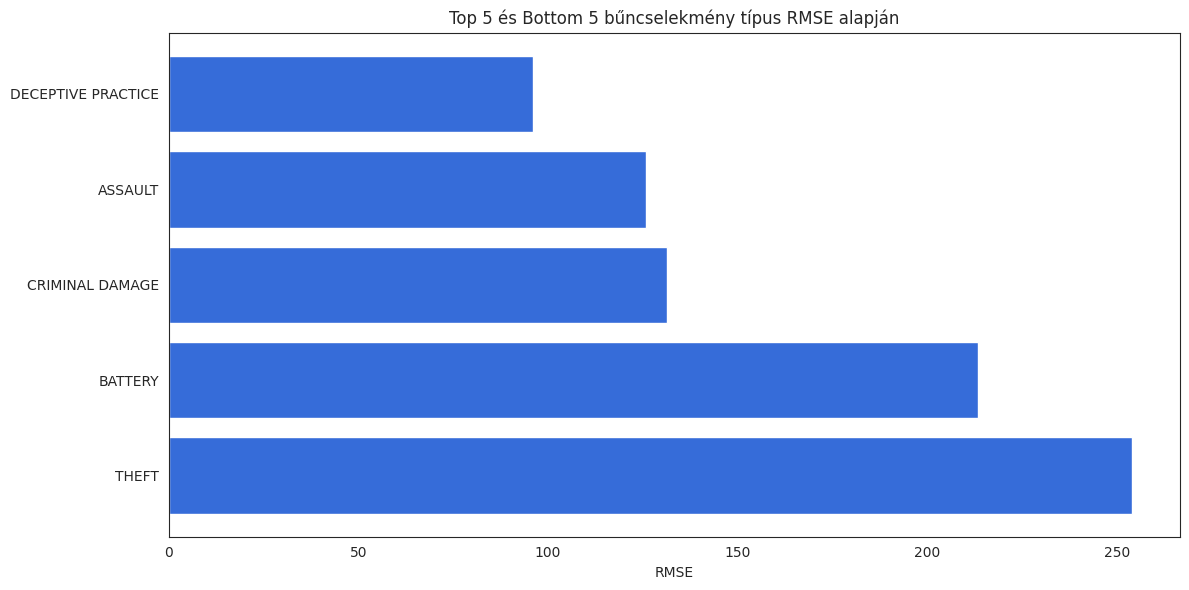

In [76]:
# Vizualizáció - legjobb és legrosszabb 5 típus RMSE szerint
plt.figure(figsize=(12, 6))
top5 = summary_by_type.head(5)
bottom5 = summary_by_type.tail(5)
viz_df = pd.concat([top5, bottom5])

plt.barh(viz_df['Primary Type'], viz_df['RMSE'])
plt.xlabel('RMSE')
plt.title('Top 5 és Bottom 5 bűncselekmény típus RMSE alapján')
plt.tight_layout()
plt.show()


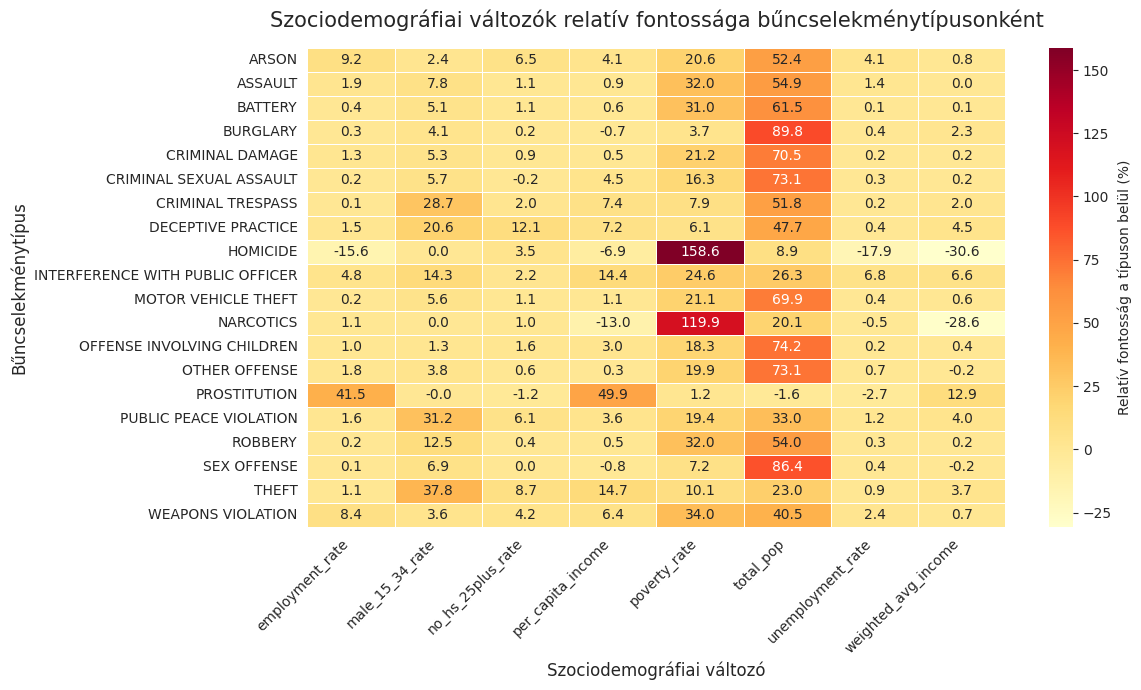

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Adatok beolvasása (a korábban elmentett CSV-ből)
# Ha a kódodban a memóriában még benne van a 'combined_permutation_importance_df',
# akkor ezt a sort ki is hagyhatod, és használhatod közvetlenül azt.
df_imp = pd.read_csv('results/permutation_importance.csv')

# 2. Csak a szociodemográfiai változók szűrése
# Kiszűrjük a rolling mean-eket és a 'Year', 'Community Area' azonosítókat
socio_features = [
    'total_pop', 'weighted_avg_income', 'employment_rate',
    'unemployment_rate', 'per_capita_income', 'poverty_rate',
    'no_hs_25plus_rate', 'male_15_34_rate'
]
df_socio = df_imp[df_imp['Feature'].isin(socio_features)].copy()

# 3. A legérdekesebb / leggyakoribb bűncselekménytípusok kiválasztása (Top 8 példa)
top_crimes = first_section.tolist()  # Ez a listád a top 8 típusod lesz, amit korábban meghatároztál
df_socio = df_socio[df_socio['Primary Type'].isin(top_crimes)]

# 4. Pivot tábla létrehozása a hőtérképhez
# Feltételezem, hogy az oszlopod neve 'Importance' vagy 'Importance Score'
# Cseréld ki a 'values' értékét, ha nálad máshogy hívják az oszlopot!
heatmap_data = df_socio.pivot(index='Primary Type', columns='Feature', values='Importance_Mean')

# 5. NORMALIZÁLÁS (Kritikus lépés!)
# Bűncselekménytípusonként (soronként) kiszámoljuk, hogy az adott változó
# hány százalékát adja a szociodemográfiai fontosságoknak.
heatmap_data_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# 6. Hőtérkép (Heatmap) megrajzolása
plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_data_pct,
    annot=True,            # Értékek megjelenítése a cellákban
    fmt=".1f",             # 1 tizedesjegy pontosság (pl. 25.4%)
    cmap="YlOrRd",         # Színskála: Sárgától (alacsony) a Pirosig (magas)
    linewidths=.5,         # Vékony elválasztó vonalak a cellák között
    cbar_kws={'label': 'Relatív fontosság a típuson belül (%)'}
)

# 7. Címek és tengelyek formázása
plt.title('Szociodemográfiai változók relatív fontossága bűncselekménytípusonként', fontsize=15, pad=15)
plt.xlabel('Szociodemográfiai változó', fontsize=12)
plt.ylabel('Bűncselekménytípus', fontsize=12)

# X tengely feliratainak elforgatása, hogy olvashatóak legyenek
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Ábra mentése nagy felbontásban a szakdolgozathoz
plt.savefig('docs/Szakdolgozat docs/Images/Results_img/socio_feature_importance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

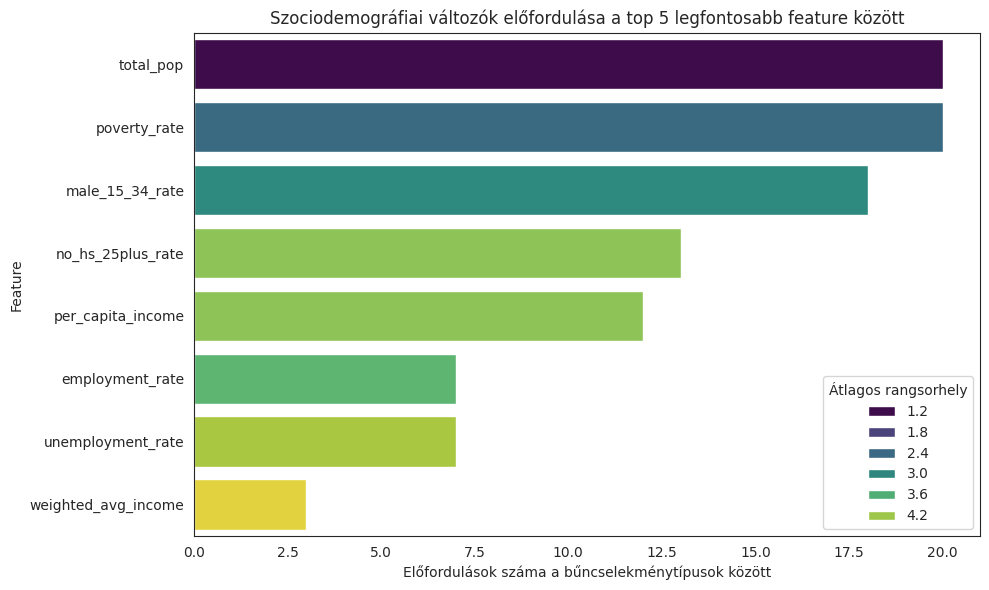

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_imp = pd.read_csv("results/permutation_importance.csv")

socio_features = [
    "total_pop", "weighted_avg_income", "employment_rate",
    "unemployment_rate", "per_capita_income", "poverty_rate",
    "no_hs_25plus_rate", "male_15_34_rate"
]

df_socio = df_imp[df_imp["Feature"].isin(socio_features)].copy()

df_socio["Rank"] = (
    df_socio
    .groupby("Primary Type")["Importance_Mean"]
    .rank(method="first", ascending=False)
)

top_n = 5
top_socio = df_socio[df_socio["Rank"] <= top_n].copy()

feature_frequency = (
    top_socio
    .groupby("Feature")
    .agg(
        Frequency=("Feature", "count"),
        Mean_Rank=("Rank", "mean"),
        Mean_Importance=("Importance_Mean", "mean")
    )
    .reset_index()
    .sort_values(["Frequency", "Mean_Rank", "Mean_Importance"], ascending=[False, True, False])
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_frequency,
    x="Frequency",
    y="Feature",
    hue="Mean_Rank",
    palette="viridis",
    dodge=False
)

plt.title(f"Szociodemográfiai változók előfordulása a top {top_n} legfontosabb feature között")
plt.xlabel("Előfordulások száma a bűncselekménytípusok között")
plt.ylabel("Feature")
plt.legend(title="Átlagos rangsorhely")
plt.tight_layout()

plt.savefig("docs/Szakdolgozat docs/Images/Results_img/top_socio_feature_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

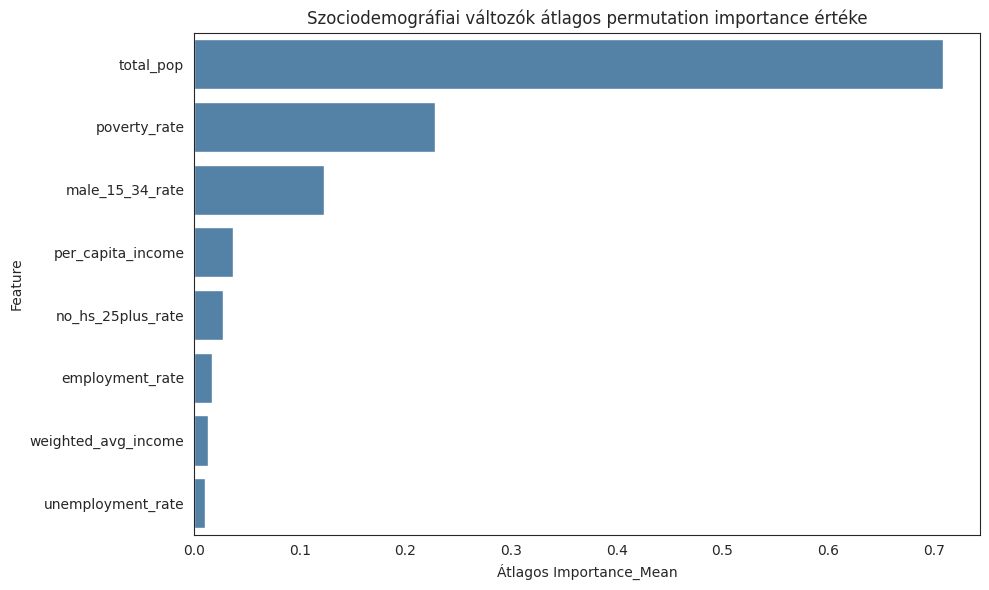

In [150]:
summary_imp = (
    df_socio
    .groupby("Feature")["Importance_Mean"]
    .mean()
    .reset_index()
    .sort_values("Importance_Mean", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=summary_imp, x="Importance_Mean", y="Feature", color="steelblue")
plt.title("Szociodemográfiai változók átlagos permutation importance értéke")
plt.xlabel("Átlagos Importance_Mean")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("docs/Szakdolgozat docs/Images/Results_img/mean_socio_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

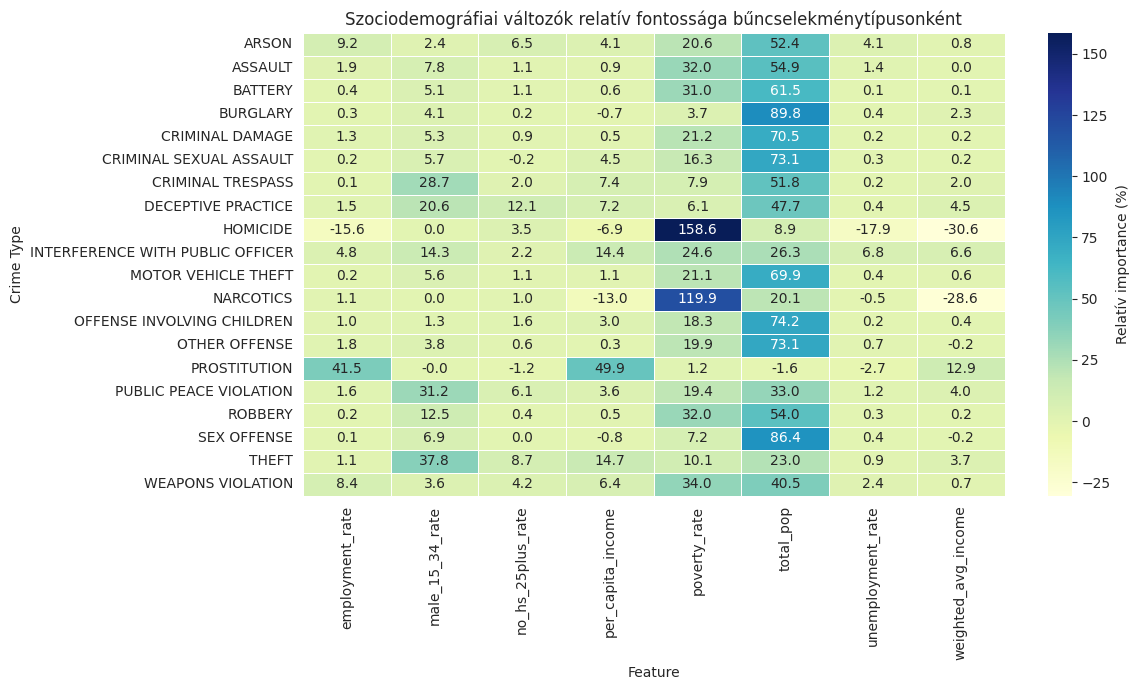

In [147]:
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_pct,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Relatív importance (%)"}
)

plt.title("Szociodemográfiai változók relatív fontossága bűncselekménytípusonként")
plt.xlabel("Feature")
plt.ylabel("Crime Type")
plt.tight_layout()
plt.savefig("docs/Szakdolgozat docs/Images/Results_img/socio_feature_relative_importance_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Residuális elemzés - maradékok vizsgálata, fontosabb jellemzők meghatározása

## 3.1 Residuals vizsgálata - teljes adatra

In [25]:
Crime_szocdem_rolling = rolling_mean(crime_szocdem, 'counts', 3)

In [26]:
model_szocdem = RandomForestRegressor(random_state=42)
feature_rolling = ["Community Area", "Year"] + ["counts_1_rollingmean", "counts_2_rollingmean", "counts_3_rollingmean"]
feature_demo = list(feature) + ["Community Area", "Year"]

In [27]:
X_train, y_train, X_test, y_test = train_test_split(Crime_szocdem_rolling, feature_rolling, "counts", 2024)
X_train_demo, y_train_demo, X_test_demo, y_test_demo = train_test_split(Crime_szocdem_rolling, feature_demo, "counts", 2024)
best_model = hyperparameter_tuning(model_szocdem,"RF_2024_by_szocdem", X_train, y_train)
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=True, criterion=absolute_error, max_depth=44, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=810; total time=   0.5s
[CV] END bootstrap=True, criterion=absolute_error, max_depth=44, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=810; total time=   0.8s
[CV] END bootstrap=True, criterion=absolute_error, max_depth=1, max_features=0.3, min_samples_leaf=4, min_samples_split=20, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, criterion=absolute_error, max_depth=1, max_features=0.3, min_samples_leaf=4, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, criterion=absolute_error, max_depth=1, max_features=0.3, min_samples_leaf=4, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, criterion=absolute_error, max_depth=1, max_features=0.3, min_samples_leaf=4, min_samples_split=20, n_estim

In [28]:
Results_test_pred, metrics_res, Results_final, metrics_final = residual_model(
    Crime_szocdem_rolling,
    name="Residual_Model_szocdem",
    rolling_features=feature_rolling,
    demo_features=feature_demo,
    target="counts",
    test_year=2024,
    model=model_szocdem
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=True, criterion=absolute_error, max_depth=44, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=810; total time=   0.5s
[CV] END bootstrap=True, criterion=absolute_error, max_depth=44, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=810; total time=   0.8s
[CV] END bootstrap=True, criterion=absolute_error, max_depth=1, max_features=0.3, min_samples_leaf=4, min_samples_split=20, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, criterion=absolute_error, max_depth=1, max_features=0.3, min_samples_leaf=4, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, criterion=absolute_error, max_depth=1, max_features=0.3, min_samples_leaf=4, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, criterion=absolute_error, max_depth=1, max_features=0.3, min_samples_leaf=4, min_samples_split=20, n_estim